In [1]:
import numpy as np
from skimage.color import rgb2hsv
import skfmm
from PIL import Image
import matplotlib.pyplot as plt
import os

width, height = 192, 192
channels = 3
data_dir = "data/human_head_clip"
start_idx, end_idx = 1001, 1376

def load_slice(index):
    path = os.path.join(data_dir, f"a_vm{index}.png")
    img = Image.open(path)
    img = np.array(img)
    return img

def rgb_hsv_from_image(img):
    r, g, b = img[..., 0] / 255, img[..., 1] / 255, img[..., 2] / 255
    hsv_img = rgb2hsv(img)
    h, s, v = hsv_img[..., 0], hsv_img[..., 1], hsv_img[..., 2]
    return r, g, b, h, s, v

# 2д эксперименты с сегментацией

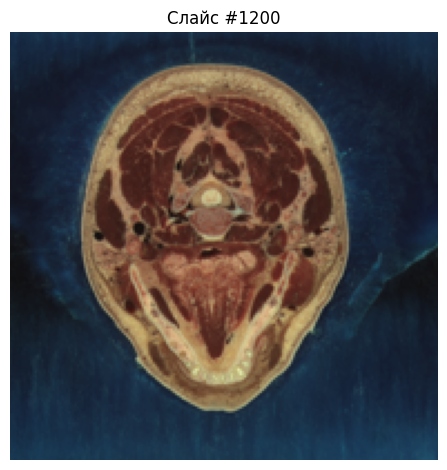

In [12]:
idx = 1200
if not (start_idx <= idx <= end_idx):
    print('Неверный индекс')
else:
    img = load_slice(idx)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Слайс #{idx}")
    plt.tight_layout()
    plt.show()

In [13]:
r, g, b, h, s, v = rgb_hsv_from_image(img)

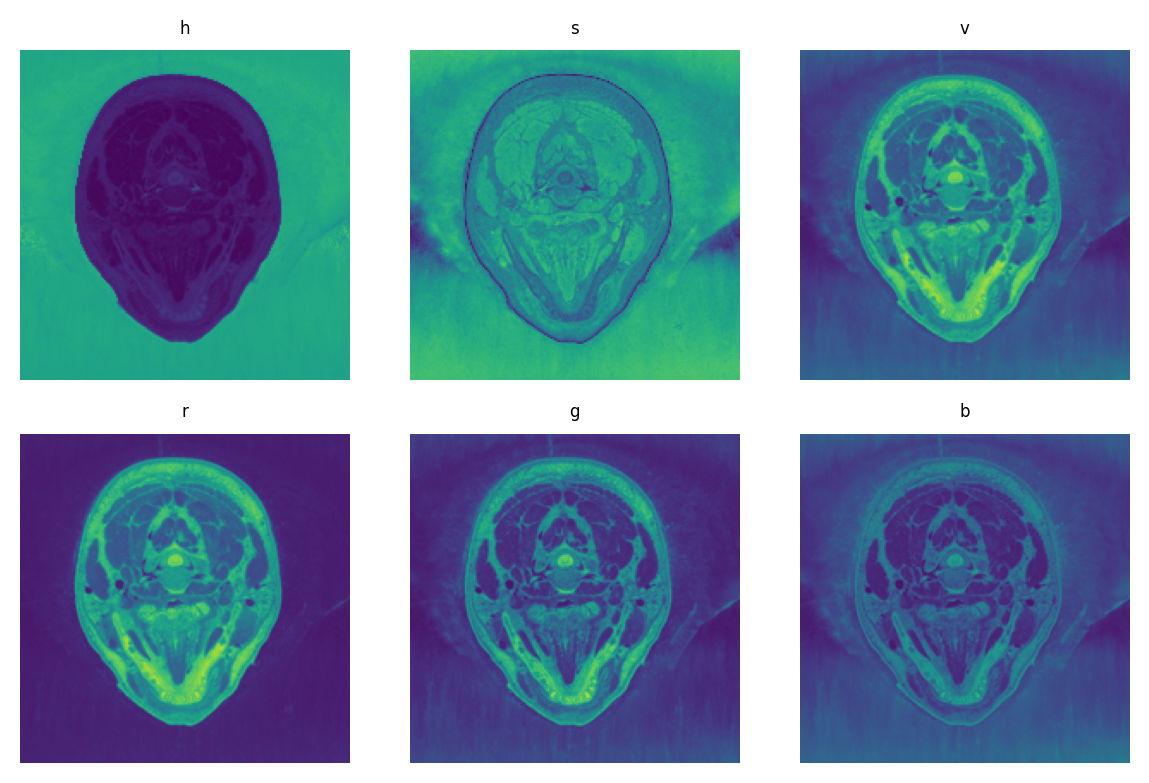

In [14]:
fig, ax = plt.subplots(nrows=2, ncols=3, dpi=200, figsize=(6, 4))

for axes, arr, title in zip(ax.reshape(-1), [h, s, v, r, g, b], ['h', 's', 'v', 'r', 'g', 'b']):
    im = axes.imshow(arr, vmin=0, vmax=1)
    axes.set_title(title, size=6)
    axes.axis('off')

plt.tight_layout()

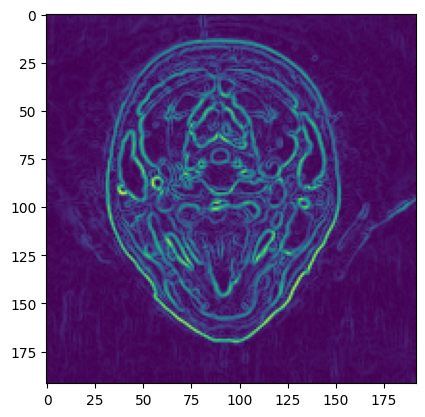

In [15]:
from skimage.filters import scharr, sobel
edges = scharr(v)
speed = 1.0 / (1.0 + edges * 100)

plt.imshow(edges);

In [16]:
gel_mask = (h > 0.5)
phi = np.ones_like(h)
phi[gel_mask] = 0

t = skfmm.travel_time(phi+0, speed)
t = t / t.max()

(-0.5, 191.5, 191.5, -0.5)

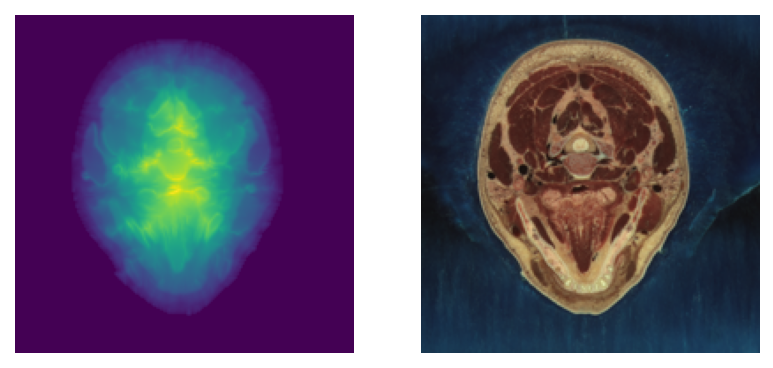

In [17]:
fig, ax = plt.subplots(ncols=2, dpi=150)
ax[0].imshow(t)
ax[1].imshow(img)
ax[0].axis('off')
ax[1].axis('off')

# 3д сегментация

In [18]:
from tqdm import tqdm

first_img = load_slice(start_idx)
width, height, _ = first_img.shape
depth = end_idx - start_idx + 1

print(f"Загружаю {depth} слоев размером {width}x{height}...")

vhp_3d_rgb = np.zeros((depth, width, height, 3), dtype=np.uint8)

for i, idx in enumerate(tqdm(range(start_idx, end_idx + 1))):
    img = load_slice(idx)
    vhp_3d_rgb[i] = img

print(f"Размер в памяти: {vhp_3d_rgb.nbytes / 1e9:.2f} ГБ")

Загружаю 376 слоев размером 192x192...


100%|██████████| 376/376 [00:00<00:00, 412.68it/s]

Размер в памяти: 0.04 ГБ


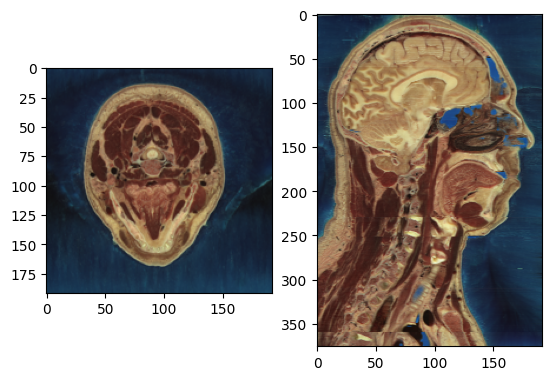

In [19]:
fig, ax = plt.subplots(ncols=2)

ax[0].imshow(vhp_3d_rgb[200])
ax[1].imshow(vhp_3d_rgb[:, :, 100, :], aspect=1/1.33);

In [20]:
r, g, b, h, s, v = rgb_hsv_from_image(vhp_3d_rgb)

edges = sobel(v)
speed = 1.0 / (1.0 + edges * 100)

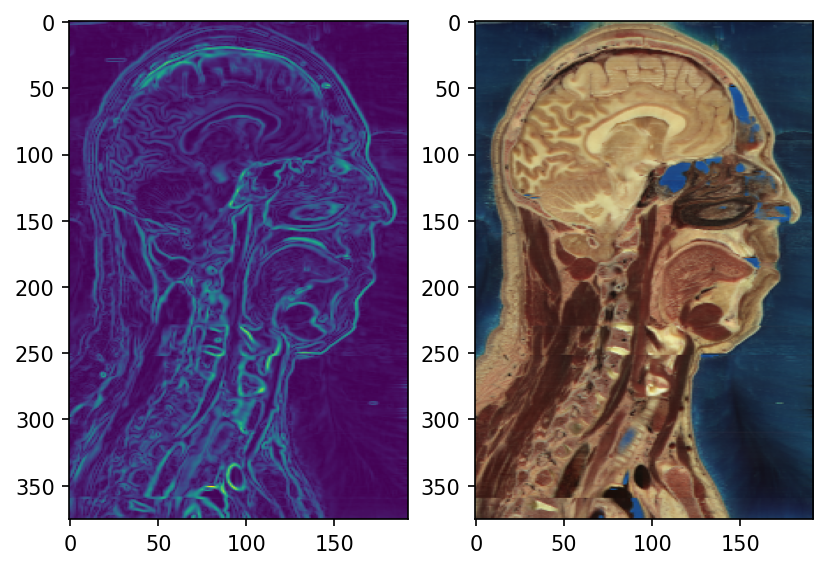

In [21]:
_, ax = plt.subplots(ncols=2, dpi=150)
ax[0].imshow(edges[:, :, 100], aspect=1/1.33)
ax[1].imshow(vhp_3d_rgb[:, :, 100, :], aspect=1/1.33);

Text(0.5, 1.0, 'Только внешний')

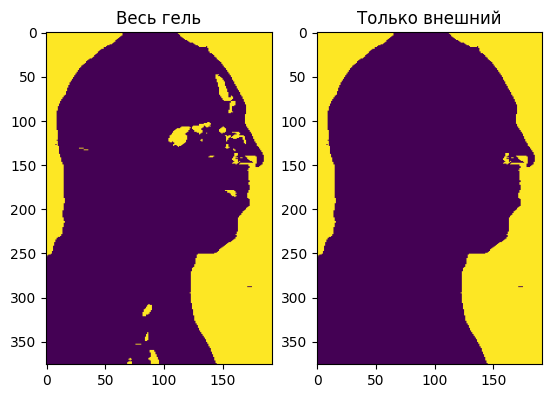

In [22]:
from skimage.morphology import flood_fill
gel_mask0 = (h > 0.5)
gel_mask = flood_fill(gel_mask0.astype(int), (0, 0, 0), 2) == 2

_, ax = plt.subplots(ncols=2)
ax[0].imshow(gel_mask0[:, :, 100], aspect=1/1.33)
ax[0].set_title('Весь гель')
ax[1].imshow(gel_mask[:, :, 100], aspect=1/1.33)
ax[1].set_title('Только внешний')


# до фикса маски

In [23]:
phi = np.ones_like(h)
phi[gel_mask0] = 0

t = skfmm.travel_time(phi, speed)
t = t / t.max()

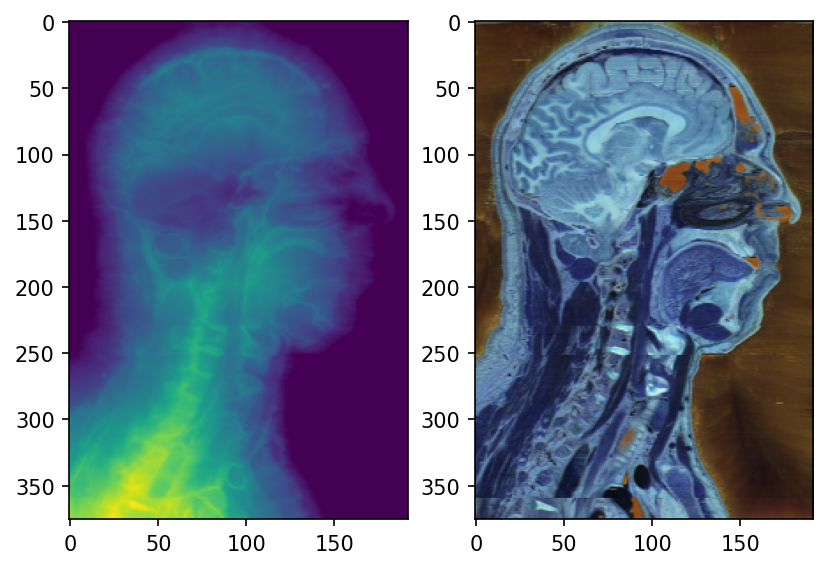

In [44]:
_, ax = plt.subplots(ncols=2, dpi=150)
ax[0].imshow(t[:, :, 100], aspect=1/1.33)
ax[1].imshow(vhp_3d_rgb[:, :, 100, ::-1], aspect=1/1.33);

# после фикса маски

In [25]:
phi = np.ones_like(h)
phi[gel_mask] = 0

t = skfmm.travel_time(phi, speed)
t = t / t.max()

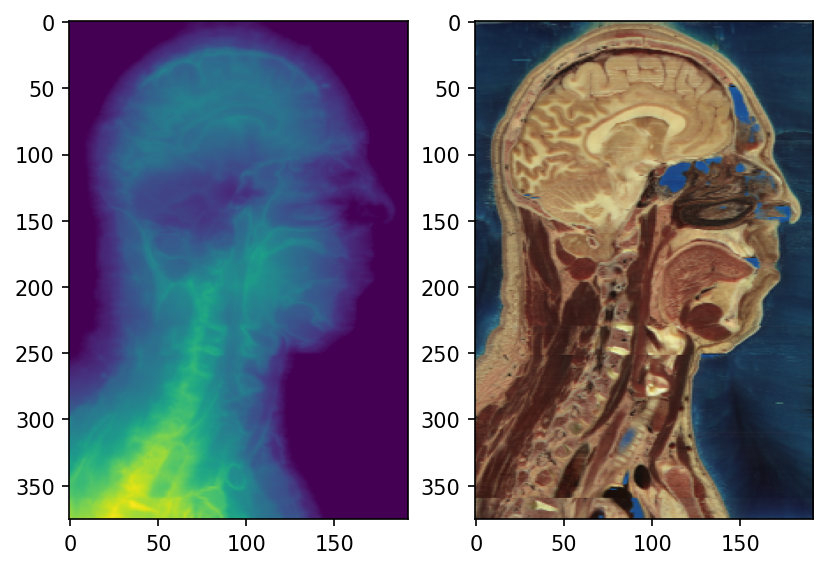

In [26]:
_, ax = plt.subplots(ncols=2, dpi=150)
ax[0].imshow(t[:, :, 100], aspect=1/1.33)
ax[1].imshow(vhp_3d_rgb[:, :, 100, :], aspect=1/1.33);

In [28]:
print(t.shape)
print(vhp_3d_rgb.shape)

(376, 192, 192)
(376, 192, 192, 3)


In [41]:
to_save = np.concatenate((t[..., np.newaxis], vhp_3d_rgb), -1)
np.save('data/vdb/to_vdb.npy', to_save)